In [ ]:
import numpy as np

# Data handling
import pandas as pd

# Data visualization (optional)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

In [ ]:
data = pd.read_excel("/content/Temperature_Humidity_100000_Dataset.xlsx")

In [ ]:
print(data.head())

   Temperature  Humidity   Status
0         31.7      67.4  Warning
1         28.9      41.1   Normal
2         32.4      61.9   Normal
3         36.4      47.6  Warning
4         28.4      51.1   Normal


In [ ]:
# Features (X)
X = data.drop("Status", axis=1)

# Label (y)
y = data["Status"]


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,      # 20% for testing
    random_state=42,      # For reproducibility
    stratify=y            # Maintains the same class distribution (recommended for classification)
)

In [ ]:
from sklearn.tree import DecisionTreeClassifier

model = DecisionTreeClassifier()
model.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
print("Decision Tree model trained successfully!")

Decision Tree model trained successfully!


In [ ]:
# Predict on the test data
y_pred = model.predict(X_test)

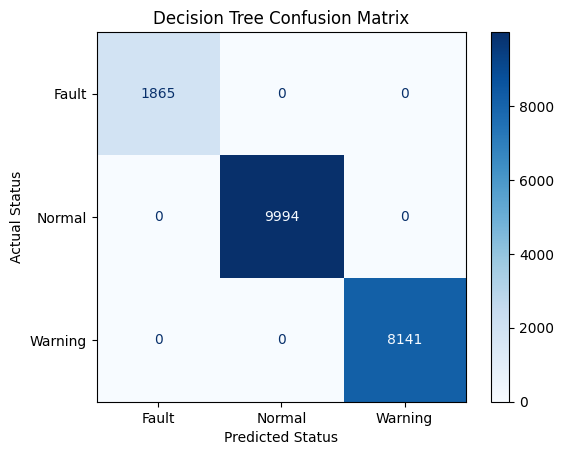

In [ ]:
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predict test data
y_pred = model.predict(X_test)

# Create confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Get actual class names
class_names = model.classes_

# Display
disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

disp.plot(cmap="Blues")

plt.title("Decision Tree Confusion Matrix")
plt.xlabel("Predicted Status")
plt.ylabel("Actual Status")
plt.show()

In [ ]:
new_data = pd.DataFrame({
    "Voltage": [230],
    "Current": [12.19   ],
    "Frequency": [50],
    "Power_Factor": [  0.584  ],
    "Active_Power": [   10 ],
    "Reactive_Power": [  2  ],
    "THD": [  10  ],
    "Temperature": [35.47],
    "Resistance": [ 0.471]
})

prediction = model.predict(new_data)

print("Prediction:", prediction[0])

if prediction[0] == 0:
    print("Healthy")
else:
    print("Fault")

Prediction: 1
Fault


In [ ]:
!pip install paho-mqtt

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 67.2/67.2 kB 3.0 MB/s eta 0:00:00


In [ ]:
import paho.mqtt.client as mqtt

broker = "broker.hivemq.com"
port = 1883
topic = "power/fault"

client = mqtt.Client()
client.connect(broker, port, 60)

client.publish(topic, "Fault Detected")

client.disconnect()

print("Message Sent")

Message Sent


/tmp/ipykernel_1747/3755002192.py:7: DeprecationWarning: Callback API version 1 is deprecated, update to latest version
  client = mqtt.Client()


In [ ]:
import json
import paho.mqtt.client as mqtt

broker = "broker.hivemq.com"
port = 1883
topic = "power/fault"

prediction = model.predict(new_data)[0]

if prediction == 1:

    client = mqtt.Client(mqtt.CallbackAPIVersion.VERSION2)
    client.connect(broker, port, 60)

    data = {
        "Status": "FAULT",
        "Voltage": 230,
        "Current": 5.2,
        "Frequency": 50,
        "Prediction": 1
    }

    client.publish(topic, json.dumps(data))
    client.disconnect()

    print("Fault message sent.")

else:
    print("Healthy - No MQTT message")

Fault message sent.


In [ ]:
result = client.publish(topic, json.dumps(data))

print(result.rc)

4


In [ ]:
!pip install paho-mqtt

import json
import time
import paho.mqtt.client as mqtt

broker = "broker.hivemq.com"
topic = "power/fault"

client = mqtt.Client(mqtt.CallbackAPIVersion.VERSION2)

client.connect(broker, 1883, 60)
client.loop_start()

data = {
    "Status": "FAULT",
    "Voltage": 230,
    "Current": 5.2,
    "Frequency": 50,
    "Prediction": 1
}

result = client.publish(topic, json.dumps(data))
result.wait_for_publish()

print("Return Code:", result.rc)
print("Message Sent")

time.sleep(2)

client.loop_stop()
client.disconnect()

Return Code: 0
Message Sent


<MQTTErrorCode.MQTT_ERR_SUCCESS: 0>